In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")

import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (balanced_accuracy_score,
    confusion_matrix, matthews_corrcoef, f1_score)

import matplotlib.pyplot as plt

from shared.config import *
from shared.metrics import (ids_evaluate,
                             tune_threshold_proba)
from shared.plots import (plot_confusion_matrix,
                           plot_pr_curve, plot_frontier)

print("Imports OK")

Config loaded successfully
Imports OK


In [2]:
# Cell 2 — Load all results
with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)
y_val  = splits["y_val"]
y_test = splits["y_test"]

with open("models/ml/opt_results.pkl", "rb") as f:
    opt_data = pickle.load(f)

with open("models/ml/trained_models.pkl", "rb") as f:
    trained = pickle.load(f)

with open("models/ml/best_xgb.pkl", "rb") as f:
    best_xgb = pickle.load(f)

with open("models/dl/dl_results.pkl", "rb") as f:
    dl_data = pickle.load(f)

X_val  = splits["X_val"]
X_test = splits["X_test"]

proba_mlp_test = dl_data["proba_mlp_test"]
proba_mlp_val  = dl_data["proba_mlp_val"]
proba_optuna   = opt_data["proba_optuna"]

print("All results loaded")

All results loaded


In [3]:
# Cell 3 — Collect validation + test probabilities
rf   = trained["rf"]
lgbm = trained["lgbm"]

proba_xgb_test  = best_xgb.predict_proba(X_test)[:, 1]
proba_rf_test   = rf.predict_proba(X_test)[:, 1]
proba_lgbm_test = lgbm.predict_proba(X_test)[:, 1]

proba_xgb_val   = best_xgb.predict_proba(X_val)[:, 1]
proba_rf_val    = rf.predict_proba(X_val)[:, 1]
proba_lgbm_val  = lgbm.predict_proba(X_val)[:, 1]

print("Probabilities collected")

Probabilities collected


In [4]:
# Cell 4 — Weighted fusion (ML + DL)
w = ENSEMBLE_WEIGHTS

proba_hybrid_test = (
    w["xgb"]  * proba_xgb_test  +
    w["rf"]   * proba_rf_test   +
    w["lgbm"] * proba_lgbm_test +
    w["mlp"]  * proba_mlp_test
)

proba_hybrid_val = (
    w["xgb"]  * proba_xgb_val  +
    w["rf"]   * proba_rf_val   +
    w["lgbm"] * proba_lgbm_val +
    w["mlp"]  * proba_mlp_val
)

th_hybrid     = tune_threshold_proba(
    proba_hybrid_val, y_val)
y_pred_hybrid = (proba_hybrid_test >= th_hybrid).astype(int)

hybrid_m = ids_evaluate("Hybrid (ML+DL)",
                          y_test.values,
                          proba_hybrid_test,
                          y_pred_hybrid, th_hybrid)
print("Hybrid ensemble metrics:")
for k, v in hybrid_m.items():
    print(f"  {k}: {v}")

Hybrid ensemble metrics:
  Model: Hybrid (ML+DL)
  Balanced Acc: 0.9651
  F1 Macro: 0.9647
  MCC: 0.9294
  Attack Recall: 0.9494
  Benign Recall: 0.9809
  Attack Precision: 0.9465
  Benign Precision: 0.982
  FAR: 0.0191
  FNR: 0.0506
  ROC-AUC: 0.9924
  PR-AUC: 0.9862


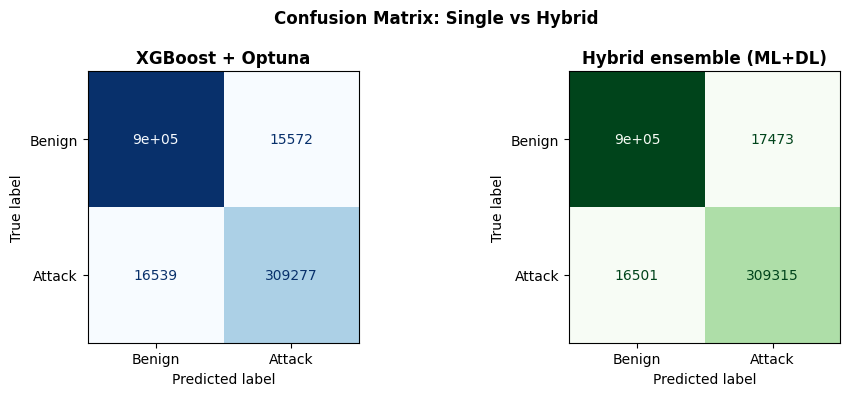

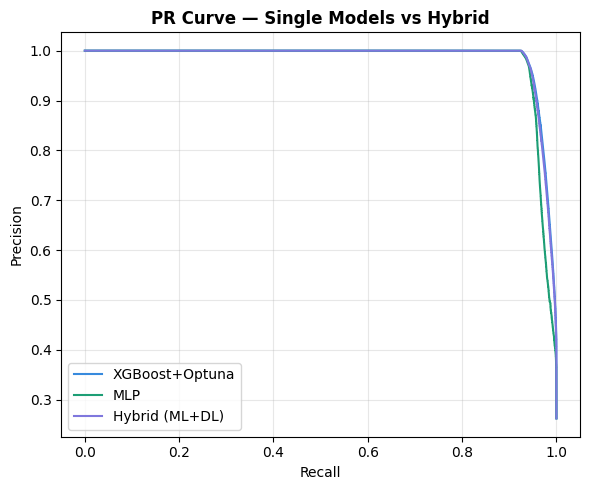

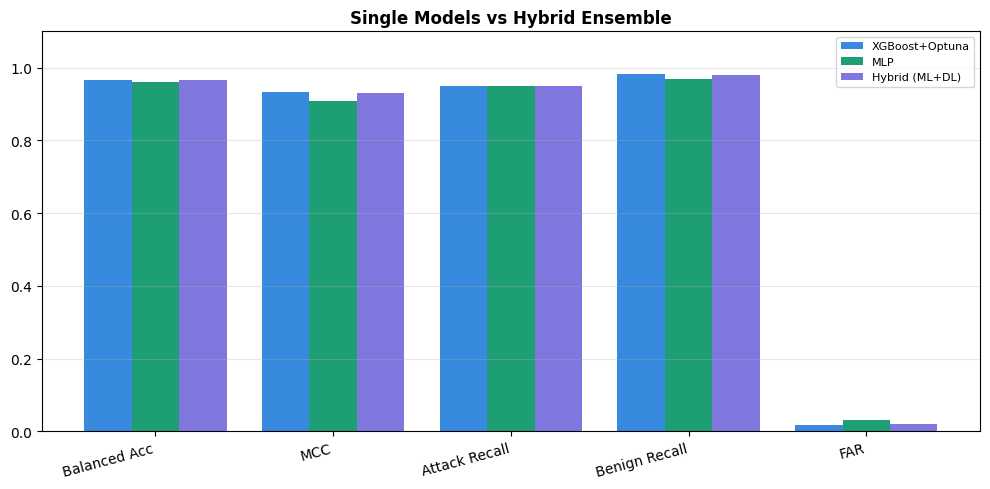

In [5]:
# Cell 5 — Hybrid vs single model comparison graphs
with open("models/ml/opt_results.pkl", "rb") as f:
    opt_data = pickle.load(f)
optuna_m = opt_data["optuna_m"]
mlp_m    = dl_data["mlp_m"]

# Confusion matrices
th_single     = tune_threshold_proba(proba_xgb_val, y_val)
y_pred_single = (proba_xgb_test >= th_single).astype(int)

from sklearn.metrics import ConfusionMatrixDisplay

cm_single = confusion_matrix(y_test.values, y_pred_single)
cm_hybrid = confusion_matrix(y_test.values, y_pred_hybrid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(
    cm_single, display_labels=["Benign","Attack"]
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("XGBoost + Optuna",
                   fontweight="bold")
ConfusionMatrixDisplay(
    cm_hybrid, display_labels=["Benign","Attack"]
).plot(ax=axes[1], colorbar=False, cmap="Greens")
axes[1].set_title("Hybrid ensemble (ML+DL)",
                   fontweight="bold")
plt.suptitle("Confusion Matrix: Single vs Hybrid",
              fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/graphs/05_hybrid_cm.png", dpi=150)
plt.show()

# PR curves
plot_pr_curve(
    y_test.values,
    {"XGBoost+Optuna" : proba_optuna,
     "MLP"            : proba_mlp_test,
     "Hybrid (ML+DL)" : proba_hybrid_test},
    title="PR Curve — Single Models vs Hybrid",
    save_path="outputs/graphs/05_hybrid_pr.png"
)

# Metrics bar
from shared.plots import plot_metrics_bar
KEY = ["Balanced Acc","MCC","Attack Recall",
       "Benign Recall","FAR"]
plot_metrics_bar(
    {"XGBoost+Optuna" : optuna_m,
     "MLP"            : mlp_m,
     "Hybrid (ML+DL)" : hybrid_m},
    KEY,
    title="Single Models vs Hybrid Ensemble",
    save_path="outputs/graphs/05_single_vs_hybrid.png"
)

Reference score: 0.9677
No drift detected — model is stable


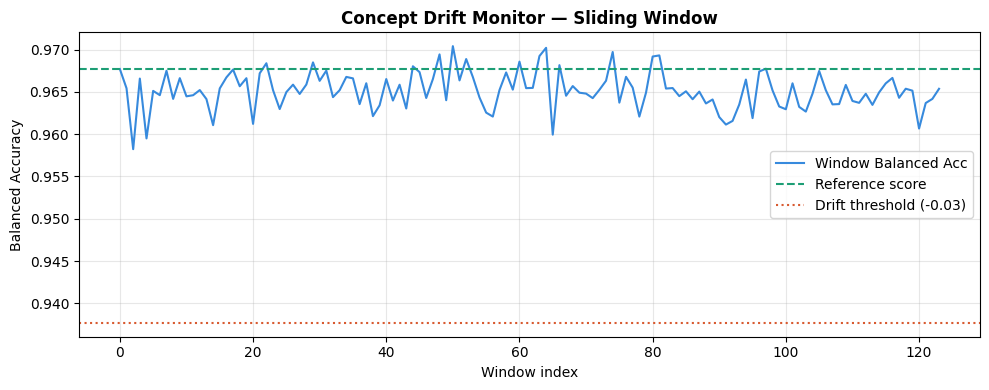

In [6]:
# Cell 6 — Concept drift detection (CDC section 5.4)
WINDOW_SIZE  = 10_000
DRIFT_THRESH = 0.03

n_windows = len(y_test) // WINDOW_SIZE
y_test_arr    = y_test.values
y_pred_arr    = y_pred_hybrid

reference_score = balanced_accuracy_score(
    y_test_arr[:WINDOW_SIZE],
    y_pred_arr[:WINDOW_SIZE]
)
print(f"Reference score: {reference_score:.4f}")

window_scores  = []
drift_detected = []

for i in range(n_windows):
    start   = i * WINDOW_SIZE
    end     = start + WINDOW_SIZE
    w_score = balanced_accuracy_score(
        y_test_arr[start:end],
        y_pred_arr[start:end]
    )
    drift = (reference_score - w_score) > DRIFT_THRESH
    window_scores.append(w_score)
    drift_detected.append(drift)
    if drift:
        print(f"  Drift at window {i} "
              f"(BAcc dropped to {w_score:.4f})")

if not any(drift_detected):
    print("No drift detected — model is stable")

# Drift monitoring plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(window_scores, color="#378ADD",
        label="Window Balanced Acc")
ax.axhline(reference_score, color="#1D9E75",
           linestyle="--", label="Reference score")
ax.axhline(reference_score - DRIFT_THRESH,
           color="#D85A30", linestyle=":",
           label=f"Drift threshold (-{DRIFT_THRESH})")

for i, d in enumerate(drift_detected):
    if d:
        ax.axvline(i, color="#D85A30", alpha=0.4)

ax.set_xlabel("Window index")
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Concept Drift Monitor — Sliding Window",
             fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/graphs/05_concept_drift.png", dpi=150)
plt.show()

In [7]:
# Cell 7 — Save hybrid results
hybrid_data = {
    "hybrid_m"         : hybrid_m,
    "proba_hybrid_test": proba_hybrid_test,
    "proba_hybrid_val" : proba_hybrid_val,
    "th_hybrid"        : th_hybrid,
    "y_pred_hybrid"    : y_pred_hybrid,
    "drift_detected"   : drift_detected,
    "window_scores"    : window_scores,
}
with open("models/hybrid/hybrid_results.pkl", "wb") as f:
    pickle.dump(hybrid_data, f)

print("Notebook 05 complete — proceed to 06_evaluation_final.ipynb")

Notebook 05 complete — proceed to 06_evaluation_final.ipynb
